In [80]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np

In [81]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [82]:
# Transformatino on dataset
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32,padding=4),
    transforms.ColorJitter(
        brightness =0.1,
        contrast=0.1,
        saturation=0.1
    ),
     transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
    
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

# Load CIFAR10 Dataset form torchvision library
train_dataset = torchvision.datasets.CIFAR10(
   root='./data',
   train=True,
   download=True,
   transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

In [83]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32,shuffle=False, pin_memory=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.5967903].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.2464638].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..1.9713104].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.390296..2.2854843].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.6366696].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657

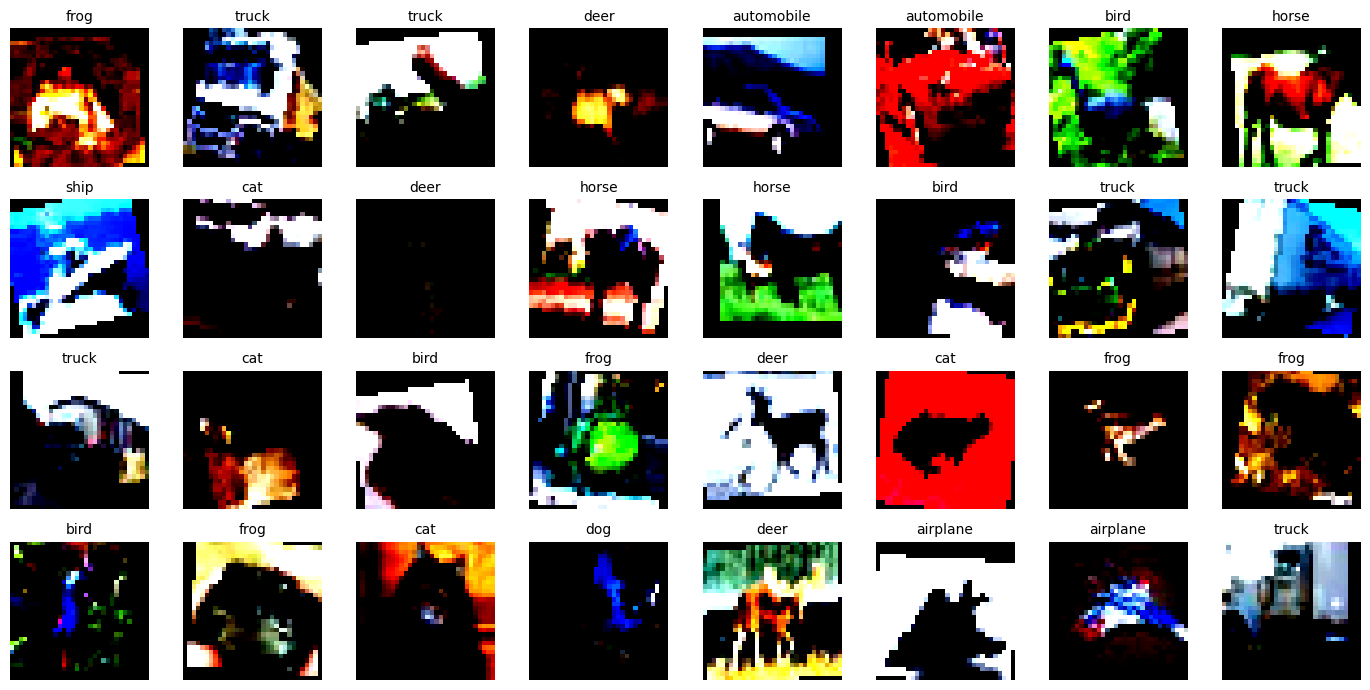

In [84]:
# Visualize dataset

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

fig, axes = plt.subplots(4, 8, figsize=(14, 7))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(classes[label], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [92]:
# making CNN class

class MyCNN(nn.Module):

  def __init__(self,num_channels):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(num_channels,32,kernel_size=3,stride=1,padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.MaxPool2d(kernel_size=2,stride=2),

        nn.Conv2d(32,64,kernel_size=3,stride=1,padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.MaxPool2d(kernel_size=2,stride=2),
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*8*8,128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(128,10),
    )

  def forward(self,x):
    x = self.features(x)
    x = self.classifier(x)

    return(x)

In [93]:
# define some parameters
learning_rate = 0.01
epochs = 100

In [94]:
# intialize model
model  = MyCNN(3)
model.to(device)
# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate,weight_decay=0.001)


In [ ]:
for i in range(epochs):
  total_loss = 0
  for batch_features,batch_labels in train_loader:

    batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)
    #forward pass
    output = model(batch_features)

    #calculate loss
    loss = criterion(output,batch_labels)

    #backward pass
    optimizer.zero_grad()
    loss.backward()

    #update parameters
    optimizer.step()

    total_loss += loss.item()

  print(f"Epoch : {i+1} ,Total Loss : {total_loss/len(train_loader)}")

Epoch : 1 ,Total Loss : 1.7391352524607897
Epoch : 2 ,Total Loss : 1.6452815174980189
Epoch : 3 ,Total Loss : 1.6128647314457274
Epoch : 4 ,Total Loss : 1.6055477639840188
Epoch : 5 ,Total Loss : 1.5931973018786576
Epoch : 6 ,Total Loss : 1.588524399471832
Epoch : 7 ,Total Loss : 1.5870892050475245
Epoch : 8 ,Total Loss : 1.5844531072230958
Epoch : 9 ,Total Loss : 1.5783529640083045
Epoch : 10 ,Total Loss : 1.5857041277949504
Epoch : 11 ,Total Loss : 1.5904134304494486
Epoch : 12 ,Total Loss : 1.5837881842715116
Epoch : 13 ,Total Loss : 1.5791312828326332
Epoch : 14 ,Total Loss : 1.5848364931455576
Epoch : 15 ,Total Loss : 1.5806489279845244


In [ ]:
total = 0 
correct = 0

with torch.no_grad():
    for batch_feature,batch_labels in test_loader:
        batch_feature,batch_labels = batch_feature.to(device),batch_labels.to(device)
        output = model(batch_feature)
        _,predict = torch.max(output,1)
        total += batch_labels.shape[0]
        correct += (predict == batch_labels).sum().item()
    print(f"Accuracy: {correct/total}")

In [ ]:
total = 0 
correct = 0

with torch.no_grad():
    for batch_feature,batch_labels in train_loader:
        batch_feature,batch_labels = batch_feature.to(device),batch_labels.to(device)
        output = model(batch_feature)
        _,predict = torch.max(output,1)
        total += batch_labels.shape[0]
        correct += (predict == batch_labels).sum().item()
    print(f"Accuracy: {correct/total}")